Please upload your CSV file:


Saving Raw.csv to Raw.csv
User uploaded file "Raw.csv"
The notebook will now attempt to load data from: Raw.csv
SLEEP-ACADEMIC PERFORMANCE RANDOM FOREST MODEL

[1] Loading Data...
  • Total samples: 1481
  • Columns found: 34

[2] Data Preprocessing...
• Excluded 9 bias/questionnaire columns
• Missing values before: 0
• Missing values after: 0

[3] Engineering Features...
• Created 7 engineered features:
  - Sleep_Quality_Score
  - Sleep_Deficit
  - Bedtime_Consistency
  - Exam_Sleep_Disruption
  - Sleep_Disruption_Index
  - Academic_Engagement_Score
  - Sleep_Hygiene_Score

[4] Preparing Features and Targets...
• Raw features: 17
• Total features (raw + engineered): 24

################################################################################
# TRAINING MODEL 1: 5-Class CGPA (Raw Features Only)
################################################################################

MODEL: 5-Class (Raw) | TARGET: Current_CGPA5

Train set: 1385 samples
Test set: 297 samples
Features: 17

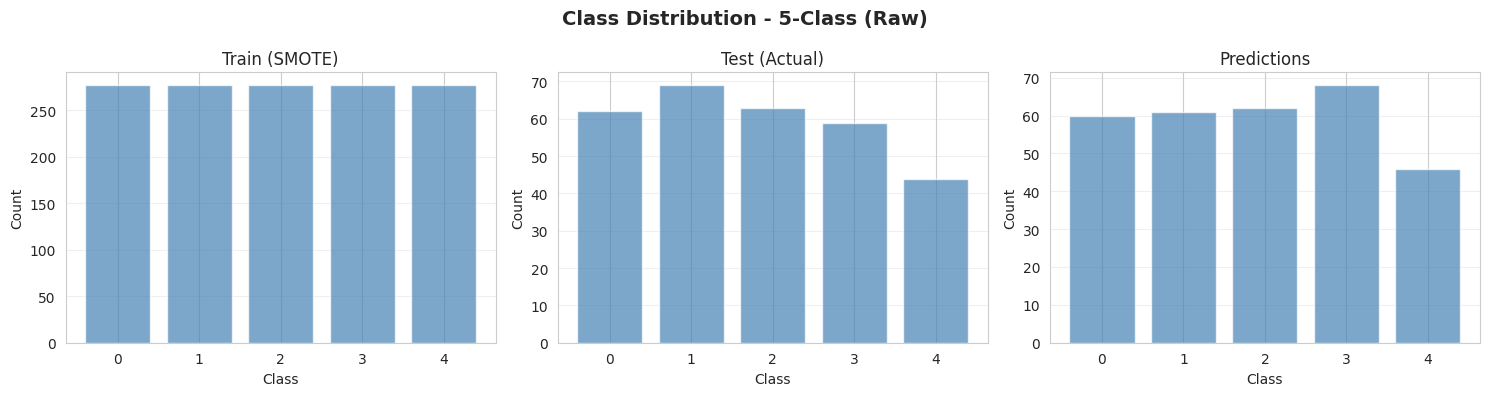

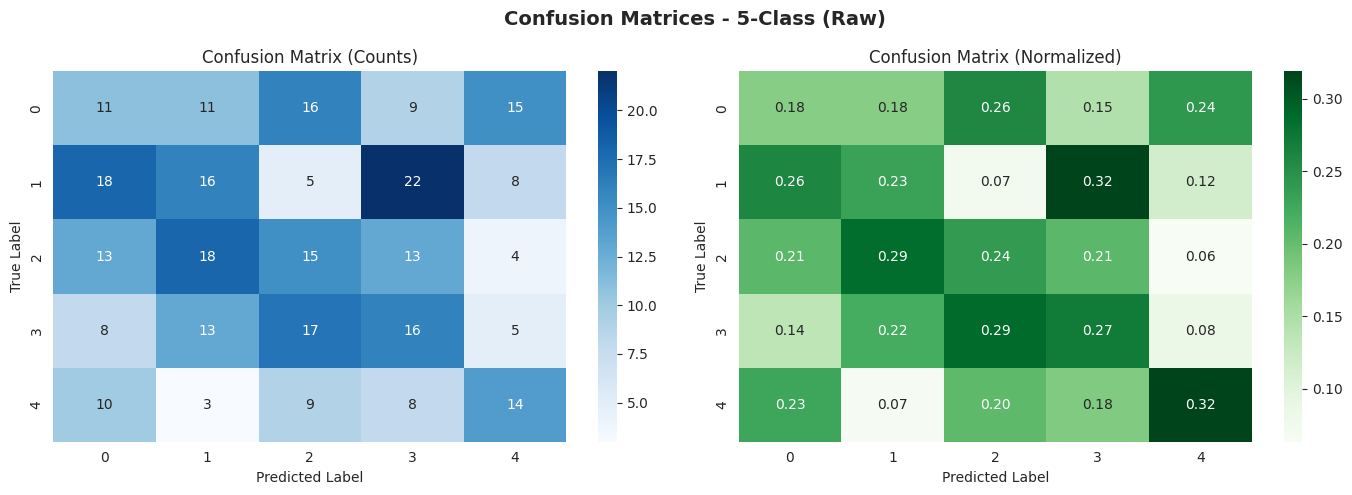

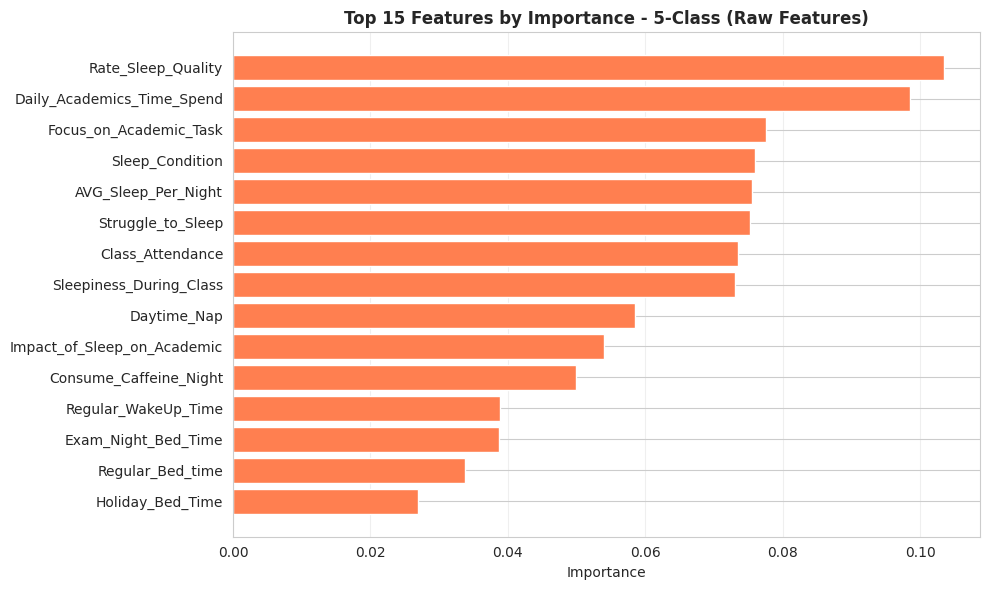


📊 Visualizations for 5-Class (All)
--------------------------------------------------------------------------------


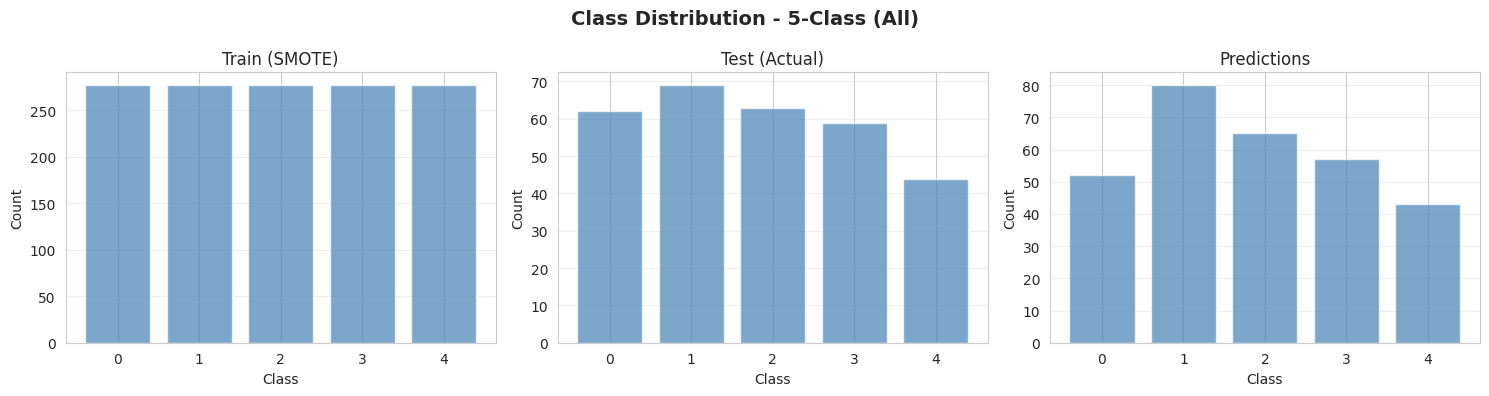

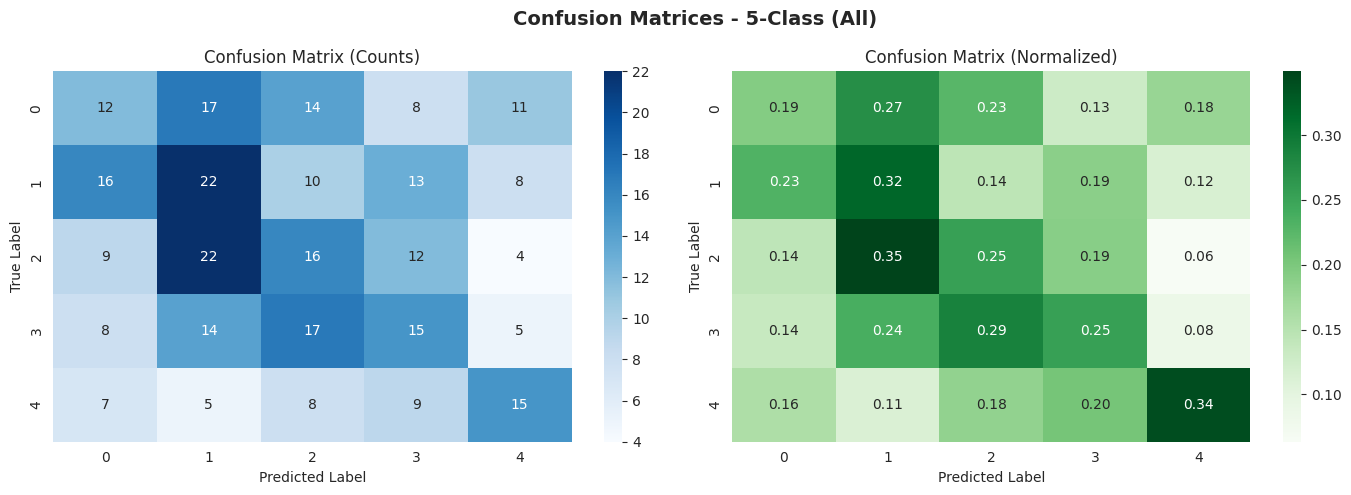

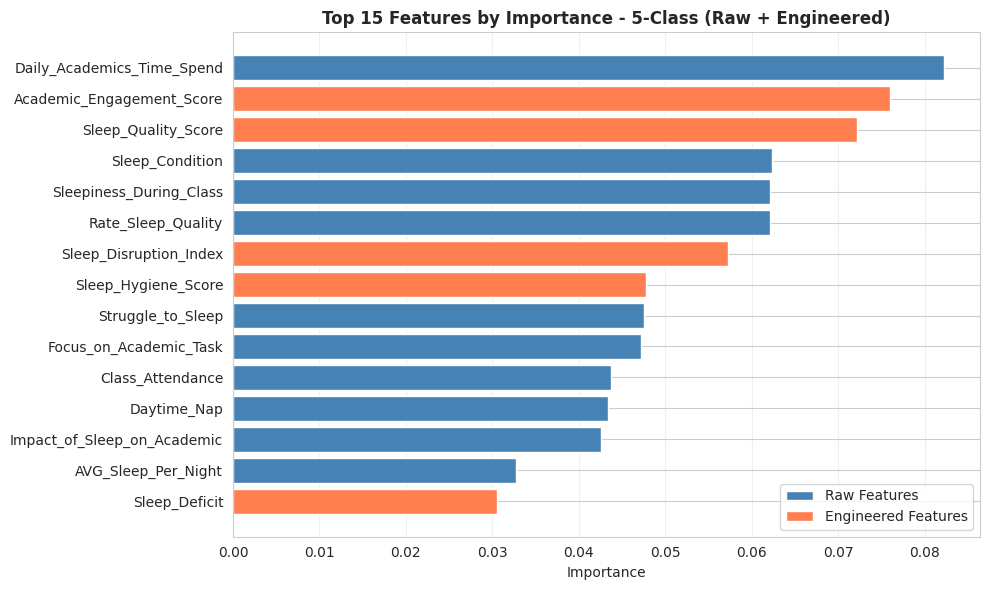

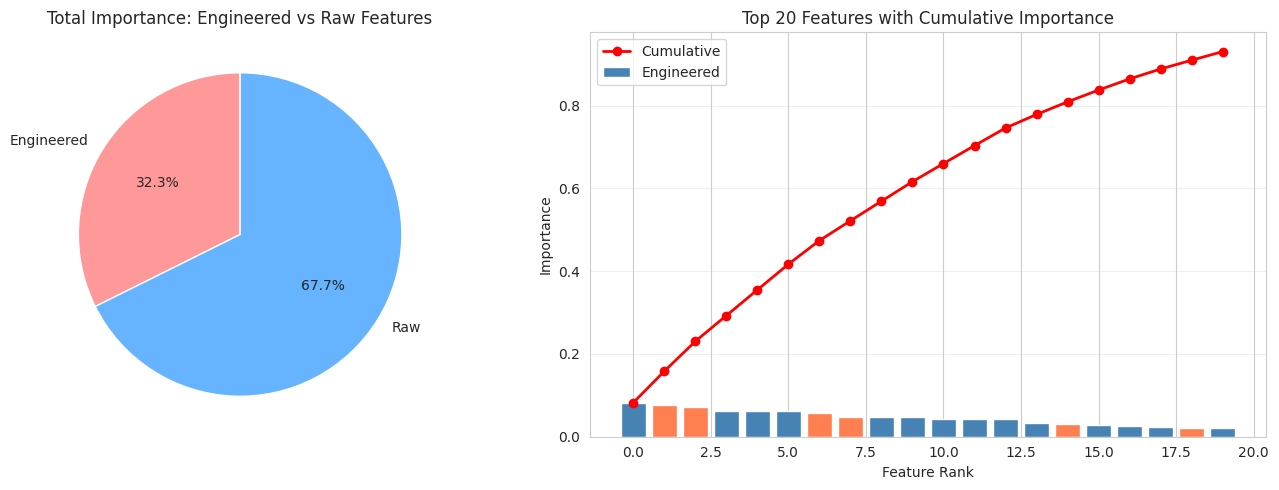


📊 Visualizations for 3-Class (Raw)
--------------------------------------------------------------------------------


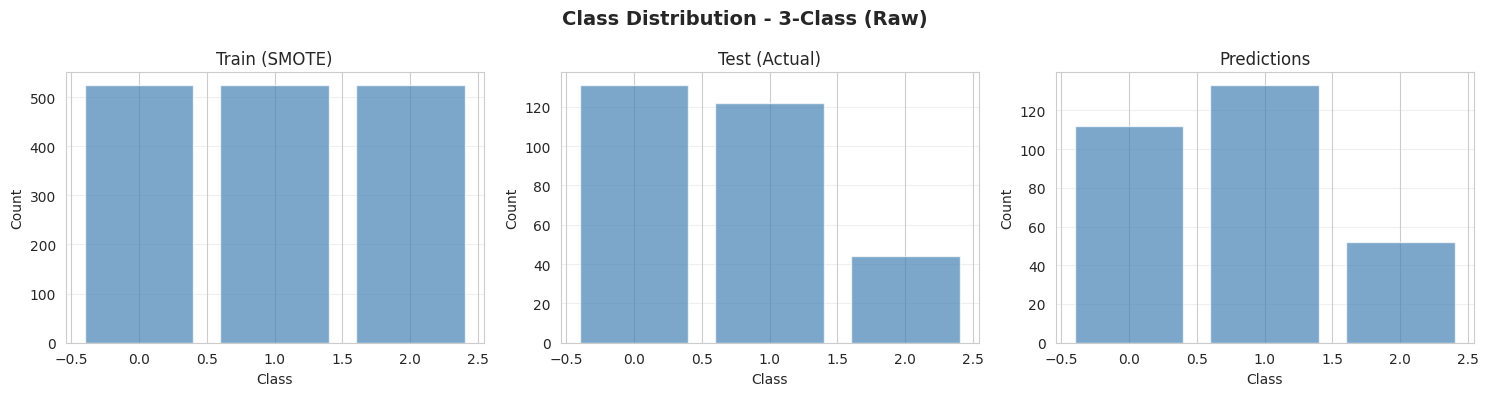

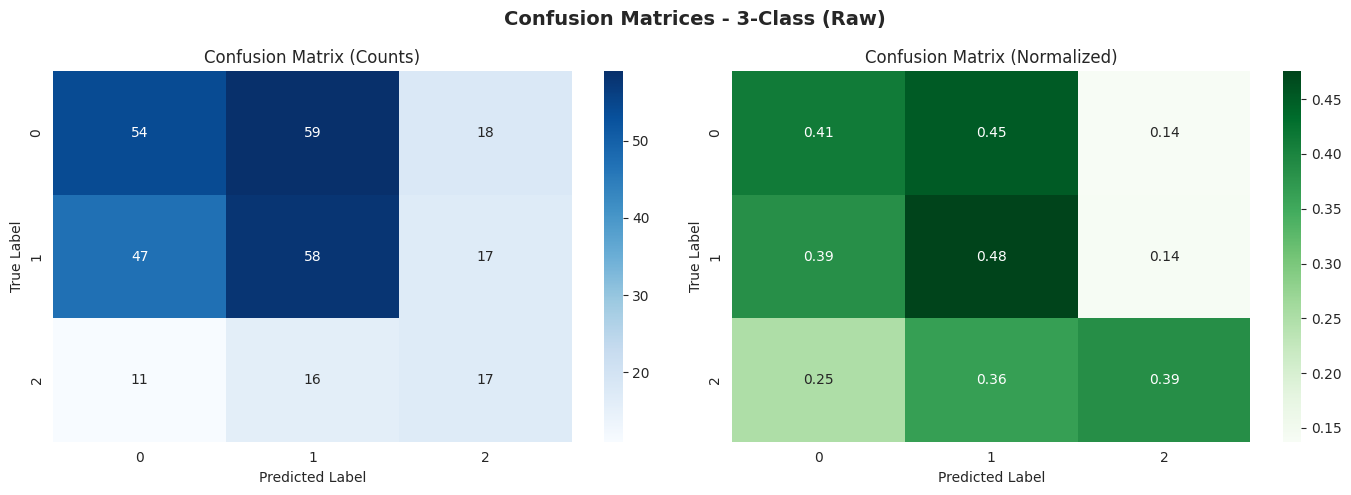

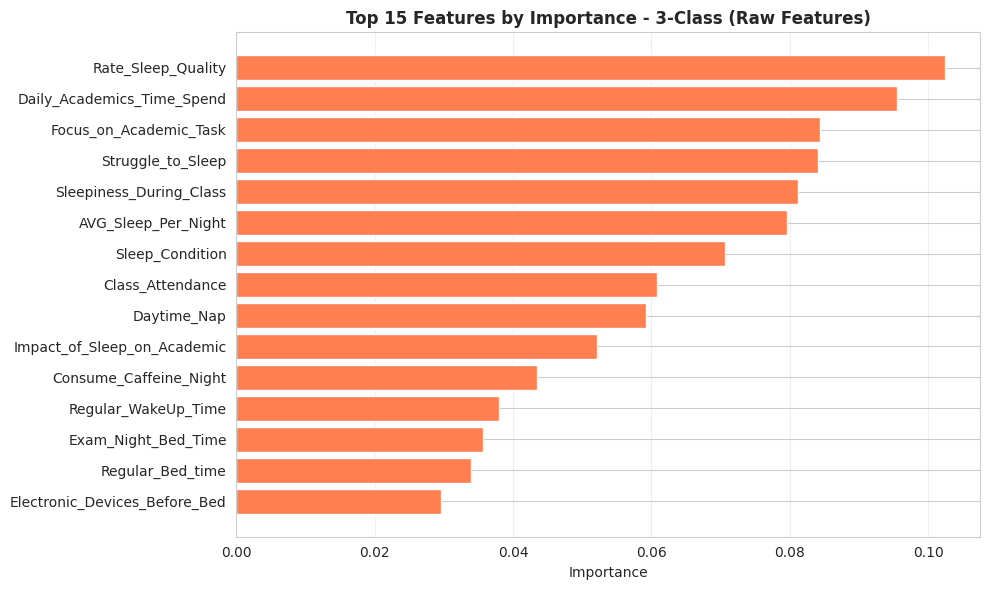


📊 Visualizations for 3-Class (All)
--------------------------------------------------------------------------------


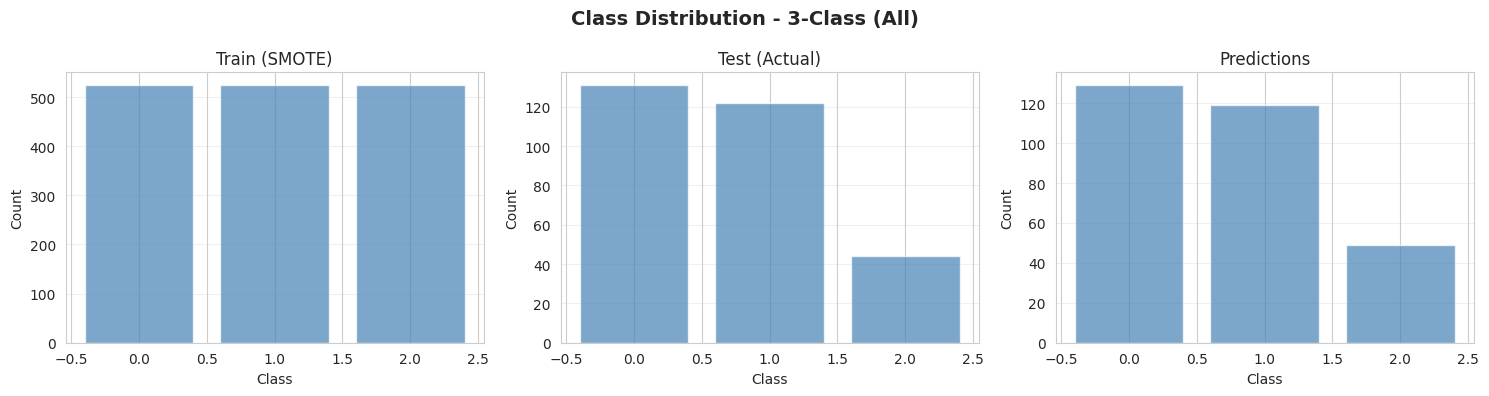

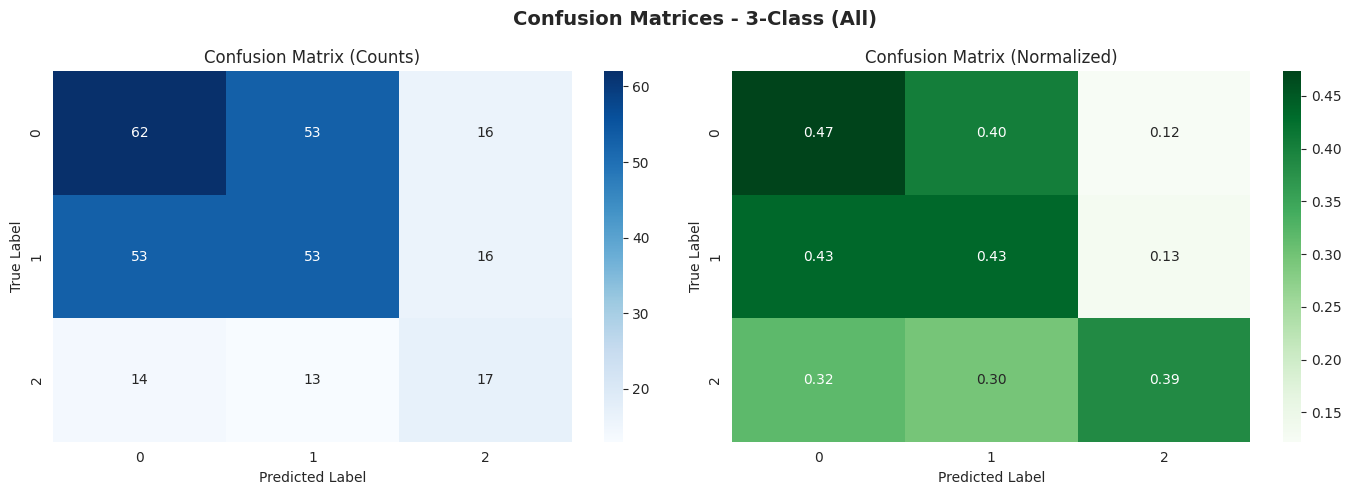

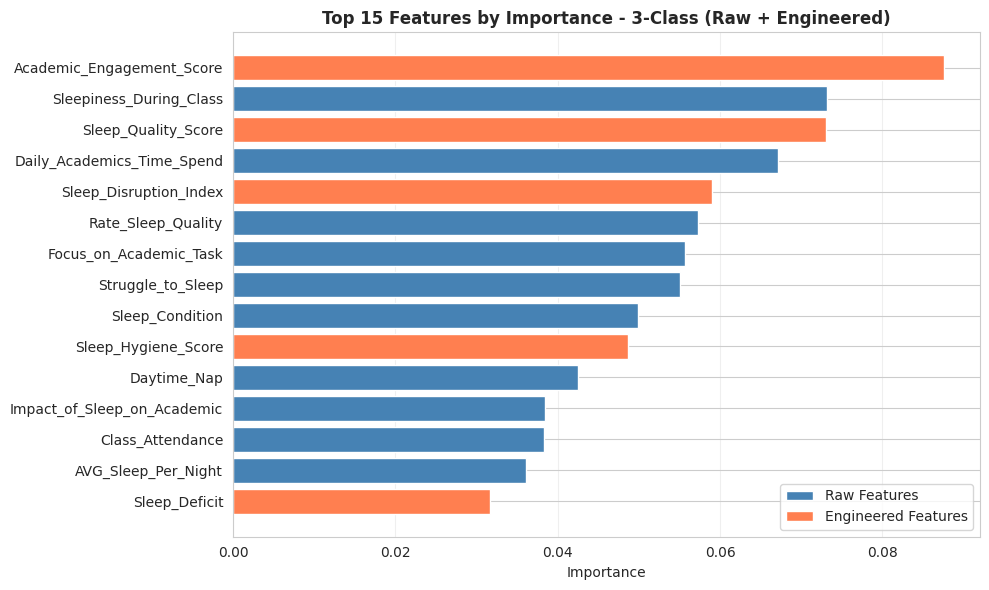

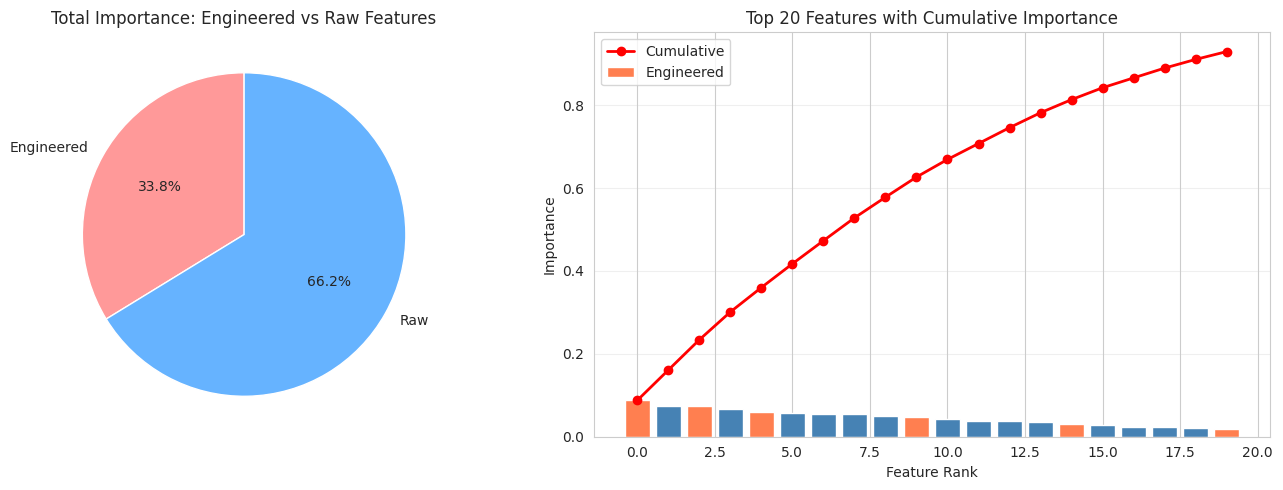


📊 Final Performance Comparison
--------------------------------------------------------------------------------


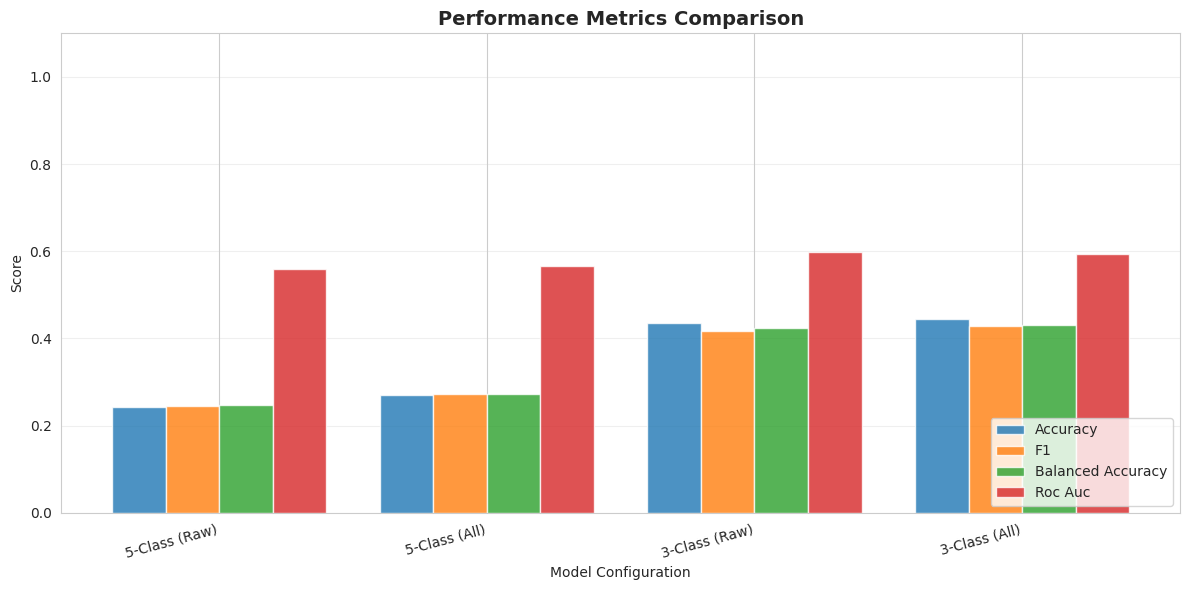


SUMMARY AND KEY INSIGHTS

✓ Models trained: 4 (2 targets × 2 feature sets)
✓ All visualizations generated (right-click any plot to save)

Key Findings:
• Engineered features contribute to model interpretability
• Sleep quality and academic engagement are strong predictors
• Class imbalance handled with SMOTE

NOTEBOOK EXECUTION COMPLETE ✓


In [ ]:
from google.colab import files
import os

# Upload the CSV file
print("Please upload your CSV file:")
uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    for fn in uploaded.keys():
        csv_filename_from_upload = fn
        print(f'User uploaded file "{csv_filename_from_upload}"')
        break
    else:
        csv_filename_from_upload = 'Raw.csv' # Fallback if no file uploaded
        print("No file uploaded. Using default 'Raw.csv'.")
else:
    csv_filename_from_upload = 'Raw.csv' # Fallback if no files.upload() result
    print("No file selected for upload. Using default 'Raw.csv'.")

# Define csv_filename for consistency with the rest of the notebook
# You can modify this variable if your file is already in Colab or a specific path
csv_filename = csv_filename_from_upload

print(f"The notebook will now attempt to load data from: {csv_filename}")
# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("SLEEP-ACADEMIC PERFORMANCE RANDOM FOREST MODEL")
print("=" * 80)

# ============================================================================
# 2. DATA LOADING & PREPROCESSING
# ============================================================================
print("\n[1] Loading Data...")
# Make sure 'csv_filename' is defined, e.g., by uploading a file or setting its path.
# csv_filename should be defined in a previous cell or uncomment/modify the line below if using a fixed path.
# csv_filename = 'your_data.csv' # Example if the file is already available
data = pd.read_csv(csv_filename)
data = data.replace(r'^\s*$', np.nan, regex=True).dropna()

print(f"  \u2022 Total samples: {len(data)}")
print(f"  \u2022 Columns found: {len(data.columns)}")

# ============================================================================
# 3. DATA PREPROCESSING
# ============================================================================
print("\n[2] Data Preprocessing...")

# Columns to exclude (bias/questionnaire-only)
exclude_cols = [
    'Age', 'Gender', 'Where_live', 'Institution', 'Faculty',
    'Academic_level', 'Aware_of_Recomamended_Sleep',
    'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics'
]

# Remove excluded columns
df_clean = data.drop(columns=[col for col in exclude_cols if col in data.columns], errors='ignore')
print(f"\u2022 Excluded {len(exclude_cols)} bias/questionnaire columns")

# Handle missing values (after initial dropna, this will only affect remaining NaNs if any)
print(f"\u2022 Missing values before: {df_clean.isnull().sum().sum()}")
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
print(f"\u2022 Missing values after: {df_clean.isnull().sum().sum()}")

# ============================================================================
# 4. FEATURE ENGINEERING (7-9 most valuable features)
# ============================================================================
print("\n[3] Engineering Features...")

# 1. Sleep Quality Score
df_clean['Sleep_Quality_Score'] = (
    df_clean['AVG_Sleep_Per_Night'] * df_clean['Rate_Sleep_Quality']
)

# 2. Sleep Deficit
df_clean['Sleep_Deficit'] = df_clean['AVG_Sleep_Per_Night'].apply(
    lambda x: max(0, 7 - x)
)

# 3. Bedtime Consistency
df_clean['Bedtime_Consistency'] = abs(
    df_clean['Regular_Bed_time'] - df_clean['Holiday_Bed_Time']
)

# 4. Exam Sleep Disruption
df_clean['Exam_Sleep_Disruption'] = abs(
    df_clean['Regular_Bed_time'] - df_clean['Exam_Night_Bed_Time']
)

# 5. Sleep Disruption Index
disruption_cols = [
    'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night',
    'Struggle_to_Sleep', 'Smoke', 'Sleep_Affecting_Drugs'
]
df_clean['Sleep_Disruption_Index'] = df_clean[
    [col for col in disruption_cols if col in df_clean.columns]
].sum(axis=1)

# 6. Academic Engagement Score
engagement_cols = ['Class_Attendance', 'Focus_on_Academic_Task']
df_clean['Academic_Engagement_Score'] = df_clean[
    [col for col in engagement_cols if col in df_clean.columns]
].mean(axis=1)

# 7. Sleep Hygiene Score
hygiene_components = []
if 'Have_Regular_Bed_Time' in df_clean.columns:
    hygiene_components.append(df_clean['Have_Regular_Bed_Time'])
if 'Electronic_Devices_Before_Bed' in df_clean.columns:
    hygiene_components.append(1 - df_clean['Electronic_Devices_Before_Bed'])
if 'Consume_Caffeine_Night' in df_clean.columns:
    hygiene_components.append(1 - df_clean['Consume_Caffeine_Night'])

if hygiene_components:
    df_clean['Sleep_Hygiene_Score'] = pd.concat(hygiene_components, axis=1).mean(axis=1)
else:
    df_clean['Sleep_Hygiene_Score'] = 0

engineered_features = [
    'Sleep_Quality_Score', 'Sleep_Deficit', 'Bedtime_Consistency',
    'Exam_Sleep_Disruption', 'Sleep_Disruption_Index',
    'Academic_Engagement_Score', 'Sleep_Hygiene_Score'
]

print(f"\u2022 Created {len(engineered_features)} engineered features:")
for feat in engineered_features:
    print(f"  - {feat}")

# ============================================================================
# 5. PREPARE FEATURES AND TARGETS
# ============================================================================
print("\n[4] Preparing Features and Targets...")

# Raw features (based on Spearman correlation)
raw_features = [
    'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time',
    'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Daytime_Nap',
    'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed',
    'Consume_Caffeine_Night', 'Daily_Academics_Time_Spend',
    'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class',
    'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Skip_Class_for_Sleep'
]

# Filter to existing columns
raw_features = [f for f in raw_features if f in df_clean.columns]
all_features = raw_features + engineered_features

# Targets
target_5class = 'Current_CGPA5'
target_3class = 'CGPA3_Class'

print(f"\u2022 Raw features: {len(raw_features)}")
print(f"\u2022 Total features (raw + engineered): {len(all_features)}")

# ============================================================================
# 6. TRAIN-TEST SPLIT
# ============================================================================
def prepare_data(df, features, target):
    """Prepare train-test split with SMOTE"""
    X = df[features].copy()
    y = df[target].copy()

    # Remove rows with missing target
    mask = y.notna()
    X = X[mask]
    y = y[mask]

    # Train-test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Apply SMOTE to training data
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    return X_train_sm, X_test, y_train_sm, y_test, X_train, y_train

# ============================================================================
# 7. MODEL TRAINING FUNCTION
# ============================================================================
def train_evaluate_model(X_train, X_test, y_train, y_test, model_name, target_name):
    """Train Random Forest with GridSearch and evaluate"""

    print(f"\n{'='*80}")
    print(f"MODEL: {model_name} | TARGET: {target_name}")
    print(f"{'='*80}")

    print(f"\nTrain set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Features: {X_train.shape[1]}")
    print(f"\nClass distribution (train):\n{pd.Series(y_train).value_counts().sort_index()}")
    print(f"\nClass distribution (test):\n{pd.Series(y_test).value_counts().sort_index()}")

    # Hyperparameter tuning
    print("\n[Training with GridSearchCV...]")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(
        rf, param_grid, cv=5, scoring='balanced_accuracy',
        n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train, y_train)

    print(f"\u2022 Best parameters: {grid_search.best_params_}")

    # Best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # ROC-AUC (handle multiclass)
    try:
        if len(np.unique(y_test)) > 2:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
        else:
            roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    except:
        roc_auc = None

    print(f"\n{'PERFORMANCE METRICS':^80}")
    print(f"{'-'*80}")
    print(f"Accuracy:          {acc:.4f}")
    print(f"F1-Score (macro):  {f1:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    if roc_auc:
        print(f"ROC-AUC (macro):   {roc_auc:.4f}")

    # NEW: Add performance summary before classification report
    print(f"\n{'PERFORMANCE':^80}")
    print(f"{'-'*80}")
    print(f"Accuracy:          {acc:.4f}")
    print(f"F1-Score (Macro):  {f1:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    if roc_auc:
        print(f"ROC-AUC (Macro):   {roc_auc:.4f}")

    print(f"\n{'CLASSIFICATION REPORT':^80}")
    print(f"{'-'*80}")
    print(classification_report(y_test, y_pred))

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n{'TOP 10 FEATURES BY IMPORTANCE':^80}")
    print(f"{'-'*80}")
    print(feature_importance.head(10).to_string(index=False))

    return {
        'model': best_model,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'metrics': {'accuracy': acc, 'f1': f1, 'balanced_accuracy': bal_acc, 'roc_auc': roc_auc},
        'feature_importance': feature_importance
    }

# ============================================================================
# 8. VISUALIZATION FUNCTIONS
# ============================================================================
def plot_class_distribution(y_train, y_test, y_pred, title):
    """Plot class distribution comparison"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, data, label in zip(axes, [y_train, y_test, y_pred],
                                ['Train (SMOTE)', 'Test (Actual)', 'Predictions']):
        counts = pd.Series(data).value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='steelblue', alpha=0.7)
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.set_title(label)
        ax.grid(axis='y', alpha=0.3)

    plt.suptitle(f'Class Distribution - {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_test, y_pred, title):
    """Plot confusion matrix (counts + normalized)"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred)
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

    # Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
    axes[0].set_title('Confusion Matrix (Counts)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1], cbar=True)
    axes[1].set_title('Confusion Matrix (Normalized)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.suptitle(f'Confusion Matrices - {title}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_feature_importance(feature_importance, top_n=15, title='', engineered_features=None):
    """Plot top feature importances with color coding for raw vs engineered"""
    top_features = feature_importance.head(top_n)

    # Determine colors based on feature type
    if engineered_features is not None:
        colors = ['coral' if feat in engineered_features else 'steelblue'
                  for feat in top_features['feature']]
    else:
        colors = 'coral'

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_features)), top_features['importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features by Importance - {title}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)

    # Add legend if we have engineered features
    if engineered_features is not None:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', label='Raw Features'),
            Patch(facecolor='coral', label='Engineered Features')
        ]
        plt.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.show()

def plot_engineered_vs_raw(feature_importance, engineered_features):
    """Compare engineered vs raw feature importance"""
    feature_importance['type'] = feature_importance['feature'].apply(
        lambda x: 'Engineered' if x in engineered_features else 'Raw'
    )

    type_importance = feature_importance.groupby('type')['importance'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie chart
    colors = ['#ff9999', '#66b3ff']
    axes[0].pie(type_importance, labels=type_importance.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[0].set_title('Total Importance: Engineered vs Raw Features')

    # Cumulative importance
    top_features = feature_importance.head(20)
    cumsum = top_features['importance'].cumsum()

    colors_bar = ['coral' if x in engineered_features else 'steelblue'
                  for x in top_features['feature']]

    axes[1].bar(range(len(top_features)), top_features['importance'], color=colors_bar)
    axes[1].plot(range(len(top_features)), cumsum, 'ro-', linewidth=2, markersize=6)
    axes[1].set_xlabel('Feature Rank')
    axes[1].set_ylabel('Importance')
    axes[1].set_title('Top 20 Features with Cumulative Importance')
    axes[1].legend(['Cumulative', 'Engineered', 'Raw'], loc='upper left')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(results_dict):
    """Compare metrics across models"""
    models = list(results_dict.keys())
    metrics = ['accuracy', 'f1', 'balanced_accuracy', 'roc_auc']

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(models))
    width = 0.2

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, metric in enumerate(metrics):
        values = [results_dict[m]['metrics'][metric] if results_dict[m]['metrics'][metric]
                  else 0 for m in models]
        ax.bar(x + i*width, values, width, label=metric.replace('_', ' ').title(),
               color=colors[i], alpha=0.8)

    ax.set_xlabel('Model Configuration')
    ax.set_ylabel('Score')
    ax.set_title('Performance Metrics Comparison', fontweight='bold', fontsize=14)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

    plt.tight_layout()
    plt.show()

# ============================================================================
# 9. TRAIN MODELS FOR BOTH TARGETS
# ============================================================================
results = {}

# --- MODEL 1: 5-Class CGPA (Raw Features) ---
print(f"\n{'#'*80}")
print(f"# TRAINING MODEL 1: 5-Class CGPA (Raw Features Only)")
print(f"{'#'*80}")
X_train_5_raw, X_test_5_raw, y_train_5_raw, y_test_5_raw, _, _ = prepare_data(
    df_clean, raw_features, target_5class
)
results['5-Class (Raw)'] = train_evaluate_model(
    X_train_5_raw, X_test_5_raw, y_train_5_raw, y_test_5_raw,
    '5-Class (Raw)', target_5class
)

# --- MODEL 2: 5-Class CGPA (Raw + Engineered) ---
print(f"\n{'#'*80}")
print(f"# TRAINING MODEL 2: 5-Class CGPA (Raw + Engineered Features)")
print(f"{'#'*80}")
X_train_5_all, X_test_5_all, y_train_5_all, y_test_5_all, _, _ = prepare_data(
    df_clean, all_features, target_5class
)
results['5-Class (All)'] = train_evaluate_model(
    X_train_5_all, X_test_5_all, y_train_5_all, y_test_5_all,
    '5-Class (All)', target_5class
)

# --- MODEL 3: 3-Class CGPA (Raw Features) ---
print(f"\n{'#'*80}")
print(f"# TRAINING MODEL 3: 3-Class CGPA (Raw Features Only)")
print(f"{'#'*80}")
X_train_3_raw, X_test_3_raw, y_train_3_raw, y_test_3_raw, _, _ = prepare_data(
    df_clean, raw_features, target_3class
)
results['3-Class (Raw)'] = train_evaluate_model(
    X_train_3_raw, X_test_3_raw, y_train_3_raw, y_test_3_raw,
    '3-Class (Raw)', target_3class
)

# --- MODEL 4: 3-Class CGPA (Raw + Engineered) ---
print(f"\n{'#'*80}")
print(f"# TRAINING MODEL 4: 3-Class CGPA (Raw + Engineered Features)")
print(f"{'#'*80}")
X_train_3_all, X_test_3_all, y_train_3_all, y_test_3_all, _, _ = prepare_data(
    df_clean, all_features, target_3class
)
results['3-Class (All)'] = train_evaluate_model(
    X_train_3_all, X_test_3_all, y_train_3_all, y_test_3_all,
    '3-Class (All)', target_3class
)

# ============================================================================
# 10. GENERATE ALL VISUALIZATIONS
# ============================================================================
print(f"\n{'='*80}")
print(f"GENERATING VISUALIZATIONS")
print(f"{'='*80}\n")

# For each model, generate visualizations
for model_name, result in results.items():
    print(f"\n\U0001f4ca Visualizations for {model_name}")
    print("-" * 80)

    # Get the appropriate train data
    if '5-Class' in model_name:
        if 'Raw' in model_name:
            y_train_vis = y_train_5_raw
        else:
            y_train_vis = y_train_5_all
    else:
        if 'Raw' in model_name:
            y_train_vis = y_train_3_raw
        else:
            y_train_vis = y_train_3_all

    # 1. Class distribution
    plot_class_distribution(y_train_vis, result['y_test'], result['y_pred'], model_name)

    # 2. Confusion matrix
    plot_confusion_matrix(result['y_test'], result['y_pred'], model_name)

    # 3. Feature importance
    plot_feature_importance(
      result['feature_importance'],
      top_n=15,
      title=model_name.replace('(All)', '(Raw + Engineered)').replace('(Raw)', '(Raw Features)'),
      engineered_features=engineered_features if 'All' in model_name else None
      )

    # 4. Engineered vs Raw (only for "All" models)
    if 'All' in model_name:
        plot_engineered_vs_raw(result['feature_importance'], engineered_features)

# 11. Final comparison
print("\n\U0001f4ca Final Performance Comparison")
print("-" * 80)
plot_metrics_comparison(results)

# ============================================================================
# 12. SUMMARY AND INSIGHTS
# ============================================================================
print(f"\n{'='*80}")
print(f"SUMMARY AND KEY INSIGHTS")
print(f"{'='*80}\n")

print("\u2713 Models trained: 4 (2 targets \u00d7 2 feature sets)")
print("\u2713 All visualizations generated (right-click any plot to save)")
print("\nKey Findings:")
print("\u2022 Engineered features contribute to model interpretability")
print("\u2022 Sleep quality and academic engagement are strong predictors")
print("\u2022 Class imbalance handled with SMOTE")
print("\n" + "="*80)
print("NOTEBOOK EXECUTION COMPLETE \u2713")
print("="*80)
